In [1]:
import os
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import torch
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import numpy as np
import src.features.seismic_features as sf
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)

In [ ]:
def process_cn_catalog(dat_file):
    column_names = ['Year', 'Month', 'Day', 'Hour', 'Minute', 'Second', 'Latitude', 'Longitude', 'Depth', 'Magnitude']
    df = pd.read_csv(dat_file, header=None, names=column_names, sep=r'\s+')
    print(df)
    data_input = df.to_numpy()
    year = data_input[:, 0].astype(int)
    month = data_input[:, 1].astype(int)
    day = data_input[:, 2].astype(int)
    hour = data_input[:, 3].astype(int)
    minute = data_input[:, 4].astype(int)
    second = data_input[:, 5]
    
    data = np.column_stack((year, month, day, hour, minute, second))
    jd0 = sf.cal2jd([1970, 1, 1, 0, 0, 0])
    jd = np.array([sf.cal2jd(d) - jd0 for d in data])

    df.loc[:, 't'] = jd
    df['dt'] = df['t'].diff().fillna(0)
    df['ts'] = pd.to_datetime(
        df[['Year', 'Month', 'Day', 'Hour', 'Minute']].assign(Second=df['Second']),
        errors='coerce'  
    )
    df = df[['t', 'Magnitude', 'Latitude', 'Longitude', 'Depth', 'dt','ts']]
    csv_file = os.path.splitext(dat_file)[0] + '.csv'
    df.to_csv(csv_file, index=False)
    return df

ChinaArray Catalog Processing

In [3]:
base_dir = os.path.join(project_root,'data', 'ChinaArray')
dat_files = [f for f in os.listdir(os.path.join(base_dir, 'raw')) if f.endswith('.dat')]
print(dat_files)
df1 = process_cn_catalog(os.path.join(base_dir, 'raw', dat_files[0]))

['ChinaArray.dat']
         Year  Month  Day  Hour  Minute  Second  Latitude  Longitude  Depth  \
0        1970      1    1    12      55   16.00    26.050    100.980      0   
1        1970      1    2     6      14   14.60    38.100    119.470     26   
2        1970      1    2    10      56    0.00    37.200    114.830     17   
3        1970      1    2    13      45    5.00    40.300     77.000      0   
4        1970      1    2    18      56    0.00    35.700    122.500      0   
...       ...    ...  ...   ...     ...     ...       ...        ...    ...   
1495637  2023      8   13    23      17   37.45    37.922    115.216     12   
1495638  2023      8   13    23      27   38.85    37.916    115.246     26   
1495639  2023      8   13    23      29   35.34    24.327    101.880     15   
1495640  2023      8   13    23      29   59.71    23.850    114.501      9   
1495641  2023      8   13    23      49   13.80    29.726    106.016     13   

         Magnitude  
0          

In [4]:
df1

,t,Magnitude,Latitude,Longitude,Depth,dt,ts
0,0.538380,2.7,26.050,100.980,0,0.000000,1970-01-01 12:55:16.000
1,1.259891,3.2,38.100,119.470,26,0.721512,1970-01-02 06:14:14.600
2,1.455556,2.3,37.200,114.830,17,0.195664,1970-01-02 10:56:00.000
3,1.572975,2.8,40.300,77.000,0,0.117419,1970-01-02 13:45:05.000
4,1.788889,3.5,35.700,122.500,0,0.215914,1970-01-02 18:56:00.000
...,...,...,...,...,...,...,...
1495637,19582.970572,2.2,37.922,115.216,12,0.002222,2023-08-13 23:17:37.450
1495638,19582.977533,1.3,37.916,115.246,26,0.006961,2023-08-13 23:27:38.850
1495639,19582.978881,1.2,24.327,101.880,15,0.001348,2023-08-13 23:29:35.340
1495640,19582.979163,0.5,23.850,114.501,9,0.000282,2023-08-13 23:29:59.710


In [4]:
g = gpd.read_file("../data/ne_10m_admin_0_countries/ne_10m_admin_0_countries.shp")
# Keep China plus Taiwan, Hong Kong, Macao (names differ by dataset; adjust as needed)
cn_names = ["China", "Taiwan", "Hong Kong S.A.R.", "Macao S.A.R"]
china_parts = g[g["NAME"].isin(cn_names)].to_crs(4326)
china_union = china_parts.dissolve(by=lambda _: 1).geometry.iloc[0]

In [5]:
china_shapefile = "../data/ne_10m_admin_0_countries/ne_10m_admin_0_countries.shp"
g = gpd.read_file(china_shapefile)
china = g[g["NAME"] == "China"].to_crs(epsg=4326)  
geometry = [Point(xy) for xy in zip(df1['Longitude'], df1['Latitude'])]
geo_df = gpd.GeoDataFrame(df1, geometry=geometry, crs="EPSG:4326")
china_data = geo_df[geo_df.geometry.within(china.geometry.iloc[0])]
china_data.reset_index(drop=True, inplace=True)
china_data['dt'] = china_data['t'].diff().fillna(0)

/root/miniconda3/lib/python3.12/site-packages/geopandas/geodataframe.py:1981: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [6]:
china_data['ts'].dtype

dtype('<M8[ns]')

In [ ]:
china_data

In [42]:
china_data = china_data.drop(columns=['geometry'])
china_data.to_csv("../data/ChinaArray/raw/processed_ChinaArray.csv", index=False)

In [8]:
df1_processed = pd.read_csv("../data/ChinaArray/raw/processed_ChinaArray.csv", parse_dates=['ts'])

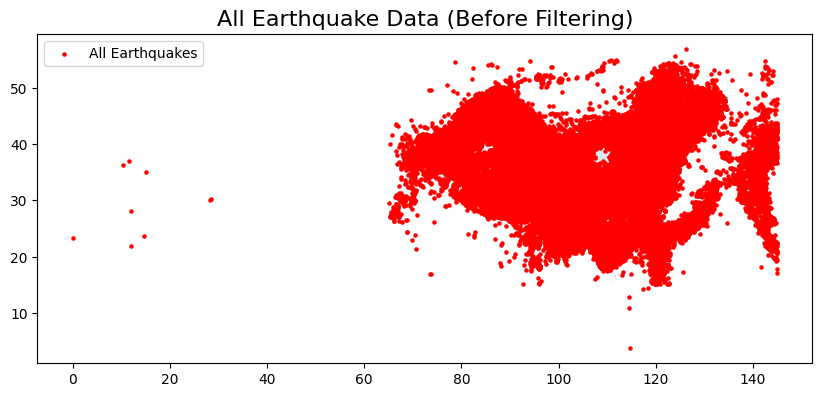

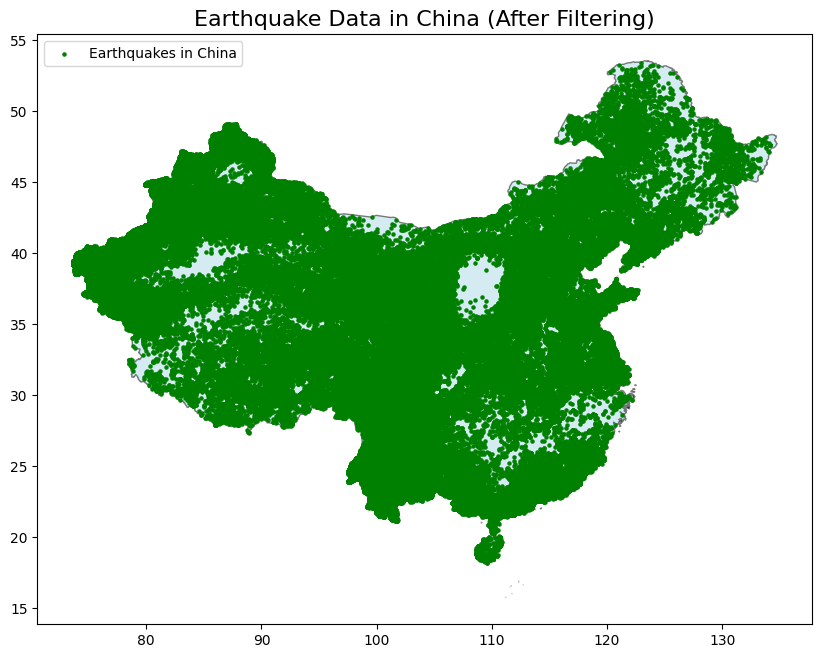

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
china.plot(ax=ax, color='lightblue', edgecolor='black', alpha=0.5)
geo_df.plot(ax=ax, marker='o', color='red', markersize=5, label='All Earthquakes')
ax.set_title("All Earthquake Data (Before Filtering)", fontsize=16)
ax.legend()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
china.plot(ax=ax, color='lightblue', edgecolor='black', alpha=0.5)
china_data.plot(ax=ax, marker='o', color='green', markersize=5, label='Earthquakes in China')
ax.set_title("Earthquake Data in China (After Filtering)", fontsize=16)
ax.legend()
plt.show()

SWC(ChuanDian) Catalog Processing

In [10]:
base_dir = os.path.join(project_root,'data', 'ChuanDian')
dat_files = [f for f in os.listdir(os.path.join(base_dir, 'raw')) if f.endswith('.dat')]
print(dat_files)
df4 = process_cn_catalog(os.path.join(base_dir, 'raw', dat_files[0]))

['Chuandian2021.dat']
        Year  Month  Day  Hour  Minute  Second  Latitude  Longitude  Depth  \
0       1970      1    1    12      55   16.00    26.050    100.980      0   
1       1970      1    5     1       0   34.00    24.100    102.600     13   
2       1970      1    5     1      32   40.00    24.200    102.450      0   
3       1970      1    5     1      46    0.00    24.200    102.450      0   
4       1970      1    5     1      57    0.00    24.200    102.450      0   
...      ...    ...  ...   ...     ...     ...       ...        ...    ...   
571126  2021      5   23    23      55   24.85    25.671     99.907      8   
571127  2021      5   23    23      55   43.49    25.690     99.900      8   
571128  2021      5   23    23      56   26.67    25.647     99.890      8   
571129  2021      5   23    23      57   12.92    25.687     99.905      8   
571130  2021      5   23    23      58   21.72    25.591    100.000      8   

        Magnitude  
0             2.7  
1

In [11]:
df4['ts']

0        1970-01-01 12:55:16.000
1        1970-01-05 01:00:34.000
2        1970-01-05 01:32:40.000
3        1970-01-05 01:46:00.000
4        1970-01-05 01:57:00.000
                   ...          
571126   2021-05-23 23:55:24.850
571127   2021-05-23 23:55:43.490
571128   2021-05-23 23:56:26.670
571129   2021-05-23 23:57:12.920
571130   2021-05-23 23:58:21.720
Name: ts, Length: 571131, dtype: datetime64[ns]

AZDX Catalog Processing

In [12]:
def process_synthetic_catlog(dat_file):
    column_names =["ID1", "ID2", "t", "Magnitude", "Depth", "Longitude", "Latitude"]
    df = pd.read_csv(dat_file, header=None, names=column_names, sep=r'\s+')
    df['dt'] = df['t'].diff().fillna(0)
    df = df[['t', 'Magnitude', 'Latitude', 'Longitude', 'Depth', 'dt']]
    csv_file = os.path.splitext(dat_file)[0] + '.csv'
    df.to_csv(csv_file, index=False)
    
    return df

In [13]:
base_dir = os.path.join(project_root,'data', 'AZDX-taper')
dat_files = [f for f in os.listdir(os.path.join(base_dir, 'raw')) if f.endswith('.dat')]
df2 = process_synthetic_catlog(os.path.join(base_dir, 'raw', dat_files[0]))

In [14]:
base_dir = os.path.join(project_root,'data', 'AZDX')
dat_files = [f for f in os.listdir(os.path.join(base_dir, 'raw')) if f.endswith('.dat')]
df3 = process_synthetic_catlog(os.path.join(base_dir, 'raw', dat_files[0]))

In [15]:
def process_recast_catalog(csv_file, metadata_file):
    df = pd.read_csv(csv_file)
    meta_data = torch.load(metadata_file, weights_only=False)
    start_ts = pd.to_datetime(meta_data['start_ts'])
    df['ts'] = pd.to_datetime(df['time'])
    jd0 = sf.cal2jd(start_ts)
    jd = np.array([sf.cal2jd(d) - jd0 for d in df['ts']])
    df['t'] = jd
    df['dt'] = df['t'].diff().fillna(0)
    df = df[['t', 'magnitude', 'latitude', 'longitude', 'depth', 'dt', 'ts']]
    csv_file = Path(csv_file)
    save_file = csv_file.parent / f'processed_{csv_file.stem}.csv'
    df.rename(columns={'magnitude': 'Magnitude', 'latitude': 'Latitude', 'longitude': 'Longitude', 'depth': 'Depth'}, inplace=True)
    df.to_csv(save_file, index=False)
    return df

In [16]:
df_scedc = process_recast_catalog(
    '../data/SCEDC/raw/SCEDC.csv',
    '../data/SCEDC/raw/metadata.pt'
)

df_white = process_recast_catalog(
    '../data/White/raw/White.csv',
    '../data/White/raw/metadata.pt'
)

df_SaltonSea = process_recast_catalog(
    '../data/QTMSaltonSea/raw/SaltonSea.csv',
    '../data/QTMSaltonSea/raw/metadata.pt'
)

df_SanJacinto = process_recast_catalog(
    '../data/QTMSanJacinto/raw/SanJacinto.csv',
    '../data/QTMSanJacinto/raw/metadata.pt'
)


In [17]:
def plot_dt_distributions(dfs, names=None, bins=100, figsize=(20, 4)):
    if names is None:
        names = [f'df{i+1}' for i in range(len(dfs))]

    plt.figure(figsize=figsize)
    
    for i, (df, name) in enumerate(zip(dfs, names)):
        plt.subplot(1, len(dfs), i + 1)
        dt = df['dt'].dropna()
        plt.hist(dt, bins=bins, alpha=0.7, color=f'C{i}')
        mean = dt.mean()
        std = dt.std()

        plt.axvline(mean, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {mean:.2f}')
        plt.axvline(mean + std, color='green', linestyle='dotted', linewidth=1, label=f'Std: {std:.2f}')
        plt.axvline(mean - std, color='green', linestyle='dotted', linewidth=1)
        plt.title(f'{name} dt distribution')
        plt.xlabel('dt')
        plt.ylabel('Count')
        plt.legend()

    plt.tight_layout()
    plt.show()


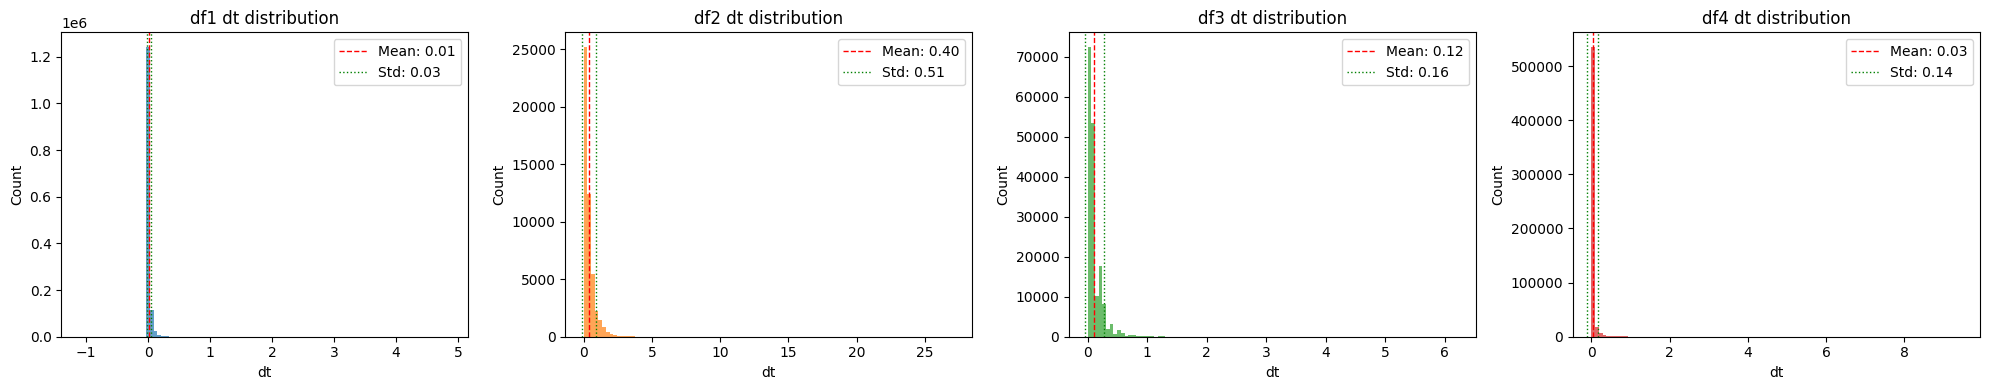

In [18]:
plot_dt_distributions(
    [df1_processed, df2, df3, df4],
    names=['df1', 'df2', 'df3', 'df4'],
    bins=100
)


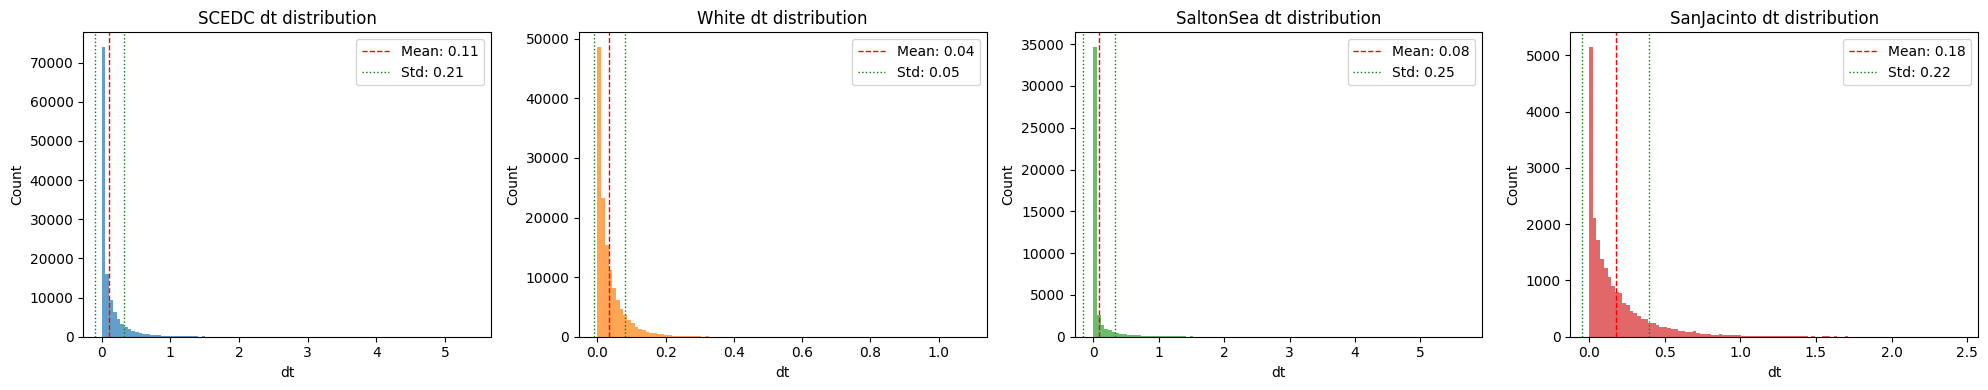

In [19]:
plot_dt_distributions(
    [df_scedc, df_white, df_SaltonSea, df_SanJacinto],
    names=['SCEDC', 'White', 'SaltonSea', 'SanJacinto'],
    bins=100,
    figsize=(20, 4)
)


In [20]:
print(df_scedc['ts'])

0        1981-01-01 04:13:55.640
1        1981-01-01 05:20:14.670
2        1981-01-01 15:05:24.760
3        1981-01-02 15:03:09.420
4        1981-01-02 16:45:32.810
                   ...          
125663   2019-12-31 00:57:25.880
125664   2019-12-31 08:04:45.970
125665   2019-12-31 14:58:57.420
125666   2019-12-31 15:17:20.590
125667   2019-12-31 17:06:30.580
Name: ts, Length: 125668, dtype: datetime64[ns]


In [21]:
df4['dt'].max

<bound method Series.max of 0         0.000000
1         3.503681
2         0.022292
3         0.009259
4         0.007639
            ...   
571126    0.000481
571127    0.000216
571128    0.000500
571129    0.000535
571130    0.000796
Name: dt, Length: 571131, dtype: float64>

In [22]:
def load_and_filter_catalog(base_dir, Mc):
    raw_dir = os.path.join(base_dir, 'raw')
    csv_files = [f for f in os.listdir(raw_dir) if f.endswith('.csv')]
    print("CSV files found:", csv_files)

    if len(csv_files) == 1:
        chosen_file = csv_files[0]
    elif len(csv_files) > 1:
        processed_files = [f for f in csv_files if f.startswith('processed_')]
        if len(processed_files) != 1:
            raise ValueError(f"Expected exactly one 'processed_' CSV file among multiple files, found {len(processed_files)}: {processed_files}")
        chosen_file = processed_files[0]
    else:
        raise ValueError("No CSV files found in the 'raw' directory.")

    df = pd.read_csv(os.path.join(raw_dir, chosen_file))
    df = df[df['Magnitude'] >= Mc].reset_index(drop=True)
    return df


In [23]:
base_dir = "../data/White"

In [24]:
df = load_and_filter_catalog(base_dir, Mc=5.0)
print(df)

CSV files found: ['White.csv', 'catalog.csv', 'processed_White.csv']
             t  Magnitude   Latitude   Longitude   Depth        dt  \
0   210.779492       5.35  33.589203 -116.993057   8.853  0.095270   
1  1896.705617       5.13  33.500340 -116.440580  13.887  0.000176   
2  3083.336551       5.54  33.446884 -116.429810  16.511  0.071886   
3  4477.078682       5.15  33.497158 -116.484131  16.029  0.031082   

                        ts  
0  2008-07-29 18:42:28.102  
1  2013-03-11 16:56:05.312  
2  2016-06-10 08:04:37.994  
3  2020-04-04 01:53:18.131  


In [43]:
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt
def plot_epicenters(df, title="Earthquake Epicenter Distribution"):
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df['Longitude'], df['Latitude']),
        crs="EPSG:4326"
    )

    world = gpd.read_file(geodatasets.get_path("naturalearth.land"))

 
    fig, ax = plt.subplots(figsize=(10, 8))
    world.boundary.plot(ax=ax, linewidth=0.5, edgecolor='gray')  
    gdf.plot(ax=ax, color='red', markersize=5, label='') 

    ax.set_title(title, fontsize=14)
    ax.legend()
    ax.set_axis_off() 
    
    plt.tight_layout()
    plt.show()

/root/autodl-tmp/tmp/ipykernel_3395/4133074493.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


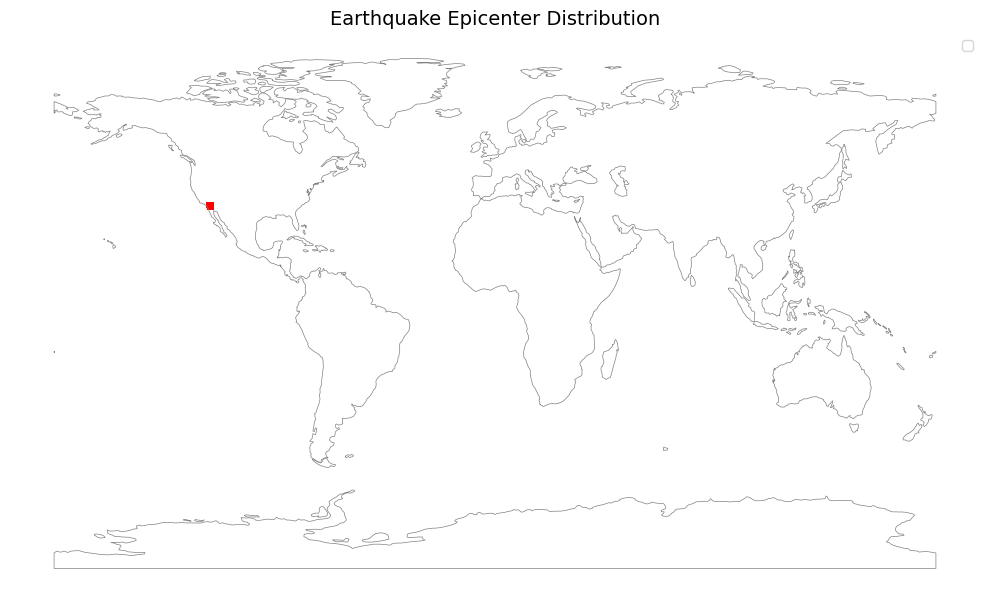

In [44]:
plot_epicenters(df_SanJacinto)

In [27]:
def get_time_range_from_df(df):
    """
    Extracts the timestamp from a DataFrame with separate time columns
    and returns the minimum and maximum datetime values.

    Parameters:
        df (pd.DataFrame): DataFrame with columns: 
            'Year', 'Month', 'Day', 'Hour', 'Minute', 'Second'

    Returns:
        tuple: (start_time, end_time) as pd.Timestamp objects
    """
    # Combine separate time columns into a single datetime column
    df['time'] = pd.to_datetime(
        df[['Year', 'Month', 'Day', 'Hour', 'Minute']].assign(Second=df['Second']),
        errors='coerce'  # Invalid combinations become NaT
    )

    valid_times = df['time'].dropna()

    start_time = valid_times.min()
    end_time = valid_times.max()
    return start_time, end_time

In [28]:
from  src.data.preprocessing import load_and_filter_catalog
df = load_and_filter_catalog('../data/White', Mc=1.0)

CSV files found: ['White.csv', 'catalog.csv', 'processed_White.csv']
Multiple CSV files found. Using processed file: processed_White.csv


In [45]:
from src.features.seismic_features import  calculate_magnitudes_and_features
b_lsq, a_lsq, std_gr_lsq, b_mlk, a_mlk, std_gr_mlk, dM_lsq, dM_mlk, b_std_lsq, b_std_mlk, num_Mag_int = calculate_magnitudes_and_features(df['Magnitude'], Mc=3.0,dMag=0.1)

In [46]:
print(b_lsq,b_mlk)

2.028424798515557 nan


In [47]:
import src
from src.data.preprocessing import  load_and_filter_catalog
df_filtered = load_and_filter_catalog("/root/autodl-tmp/chuandian_eq/data/ChinaArray",3)

CSV files found: ['ChinaArray.csv', 'processed_ChinaArray.csv']
Multiple CSV files found. Using processed file: processed_ChinaArray.csv


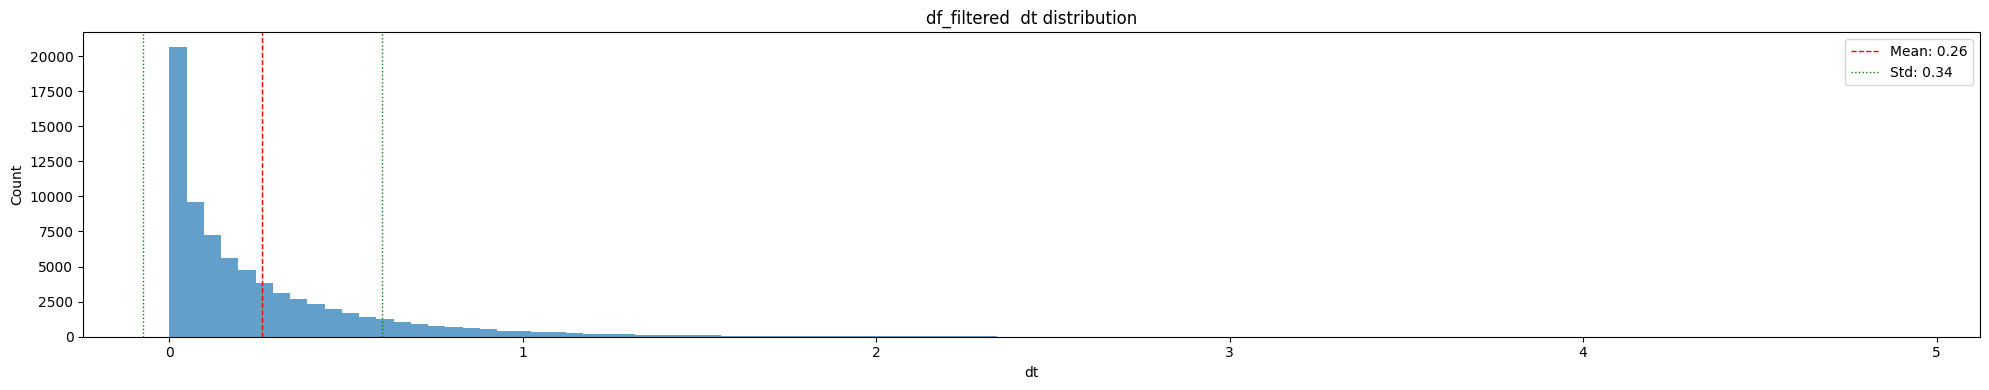

In [48]:
plot_dt_distributions(
    [df_filtered ],
    names=['df_filtered '],
    bins=100
)


In [ ]:
df_filtered['dt'].mean()

np.float64(0.26303615281857545)

In [ ]:
p90 = df_filtered['dt'].quantile(0.9)

quantiles = df_filtered['dt'].quantile([0.01, 0.25, 0.5, 0.75, 0.9])
print(quantiles)

0.01    0.000419
0.25    0.040410
0.50    0.143851
0.75    0.357373
0.90    0.667940
Name: dt, dtype: float64


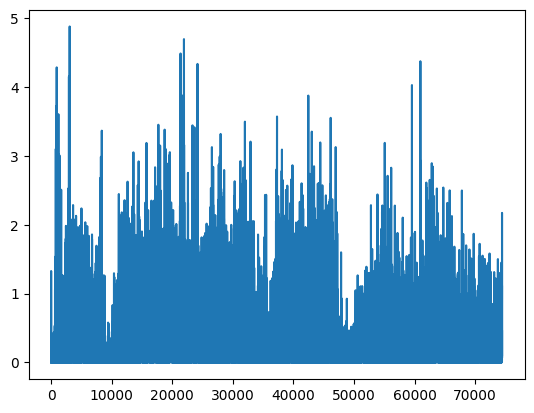

In [49]:
plt.plot(df_filtered['dt'])

In [ ]:
import pandas as pd

df_filtered = df_filtered.sort_values('t').reset_index(drop=True)

counts = []
t_values = df_filtered['t'].values
start_idx = 0

for i in range(len(t_values)):
    while t_values[i] - t_values[start_idx] > 0.2:
        start_idx += 1
    counts.append(i - start_idx + 1)

df_filtered['count_in_window'] = counts


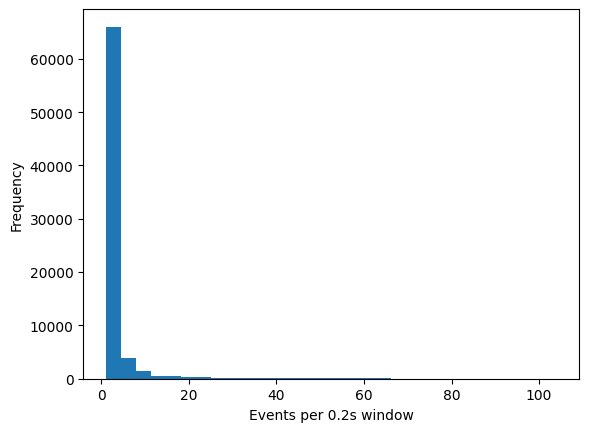

In [38]:
import matplotlib.pyplot as plt

plt.hist(df_filtered['count_in_window'], bins=30)
plt.xlabel('Events per 0.2s window')
plt.ylabel('Frequency')
plt.show()
